In [2]:
import os
from dotenv import load_dotenv
from langgraph.graph import START, END, StateGraph, MessagesState
from langchain_groq import ChatGroq
from typing_extensions import TypedDict
#REDUCERS
from typing import Annotated
from langgraph.graph.message import add_messages
load_dotenv()
groq_api_key = os.getenv("GROQ_API_KEY")

C:\Softwares\Python\pythoncore-3.14-64\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1
C:\Users\ybalasaraswa\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from langchain_core.messages import BaseMessage

class State(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages] #this will ensure that the messages are added to the list rather than replacing it

In [4]:
llm = ChatGroq(
    api_key=groq_api_key,
    model="openai/gpt-oss-120b"
)
# llm.invoke("Hello, how are you?")

In [5]:
def chatBot(state: State): #this function takes the current state of the conversation (which includes the message history) and returns a response from the LLM based on that history
    response = llm.invoke(state['messages'])
    return {
        "messages": [response]
    }

In [6]:
graph = StateGraph(State) #this creates a new state graph with the defined state structure
graph.add_node("chatbot", chatBot) #this adds a node to the graph that represents the chatbot function
graph.add_edge(START,"chatbot") #this defines the flow of the conversation, starting from the START node to the chatbot node
graph.add_edge("chatbot",END) #this defines that after the chatbot node is executed, the conversation can end
compiled_graph = graph.compile() #this compiles the graph into an executable form

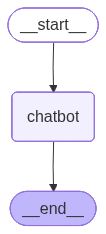

In [7]:
from IPython.display import Image,display
try:
    display(Image(compiled_graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Graph visualization is not supported in this environment.")

In [8]:
from langchain_core.messages import HumanMessage

compiled_graph.invoke({
    'messages': [HumanMessage(content="Hii !!")]
})

{'messages': [HumanMessage(content='Hii !!', additional_kwargs={}, response_metadata={}, id='b61b7bd6-8c06-4b6c-8f1c-70abd41bdd31'),
  AIMessage(content='Hey there! 👋 How can I help you today?', additional_kwargs={'reasoning_content': 'We need to respond. The user says "Hii !!". It\'s a greeting. We can respond politely. No disallowed content. Should be friendly.'}, response_metadata={'token_usage': {'completion_tokens': 53, 'prompt_tokens': 74, 'total_tokens': 127, 'completion_time': 0.115980587, 'completion_tokens_details': {'reasoning_tokens': 32}, 'prompt_time': 0.014537603, 'prompt_tokens_details': None, 'queue_time': 0.057275519, 'total_time': 0.13051819}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_a09bde29de', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cc365-3840-72e0-ae3f-d3425bd2799a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 74, 'output_tokens': 53, 'total

In [10]:
print("Using stream_mode='values':")
for event in compiled_graph.stream({"messages":[HumanMessage(content="hay I want to play something!!")]}, stream_mode="values"):
    print("---")
    for message in event["messages"]:
        print(f"{message.__class__.__name__}: {message.content}")

Using stream_mode='values':
---
HumanMessage: hay I want to play something!!
---
HumanMessage: hay I want to play something!!
AIMessage: Hey there! 🎉 I’m ready whenever you are—what kind of fun are you in the mood for?

- **Trivia quiz** (movies, science, pop culture, etc.)  
- **Word games** (riddles, anagrams, hang‑man)  
- **Choose‑your‑own‑adventure** story  
- **Number puzzles** (Sudoku, 24‑game, logic grids)  
- **Simple text‑based board games** (tic‑tac‑toe, battleship, connect‑4)  

Or if you have something else in mind, just let me know and we’ll jump right in! 🚀
